In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('./data/시도별_전출입_인구수.xlsx')

df.head()

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8808256,8487275,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226
2,NaN,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,2025358,1873188,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937
3,NaN,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,514502,519310,519334,508043,461042,478451,485710,507031,459015,439073
4,NaN,대구광역시,-,-,-,-,-,-,-,-,...,409938,398626,370817,370563,348642,351873,350213,351424,328228,321182


In [5]:
df = df.ffill()
df.head()

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8808256,8487275,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226
2,전국,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,2025358,1873188,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937
3,전국,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,514502,519310,519334,508043,461042,478451,485710,507031,459015,439073
4,전국,대구광역시,-,-,-,-,-,-,-,-,...,409938,398626,370817,370563,348642,351873,350213,351424,328228,321182


In [6]:
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시') 
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul = df_seoul.rename({'전입지별':'전입지'}, axis=1)
df_seoul = df_seoul.set_index('전입지')
df_seoul

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,3028911,2441242,...,2083352,1925452,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423
부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,29856,28542,...,17353,17738,17418,18816,16135,16153,17320,17009,15062,14484
대구광역시,-,-,-,-,-,-,-,-,-,-,...,9720,10464,10277,10397,10135,10631,10062,10191,9623,8891
인천광역시,-,-,-,-,-,-,-,-,-,-,...,50493,45392,46082,51641,49640,47424,43212,44915,43745,40485
광주광역시,-,-,-,-,-,-,-,-,-,-,...,10846,11725,11095,10587,10154,9129,9759,9216,8354,7932
대전광역시,-,-,-,-,-,-,-,-,-,-,...,13515,13632,13819,13900,14080,13440,13403,13453,12619,11815
울산광역시,-,-,-,-,-,-,-,-,-,-,...,5057,4845,4742,5188,5691,5542,6047,5950,5102,4260
세종특별자치시,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,2998,2851,6481,7550,5943,5813
경기도,130149,150313,93333,143234,149045,253705,202276,207722,237684,278411,...,412408,398282,410735,373771,354135,340801,332785,359337,370760,342433


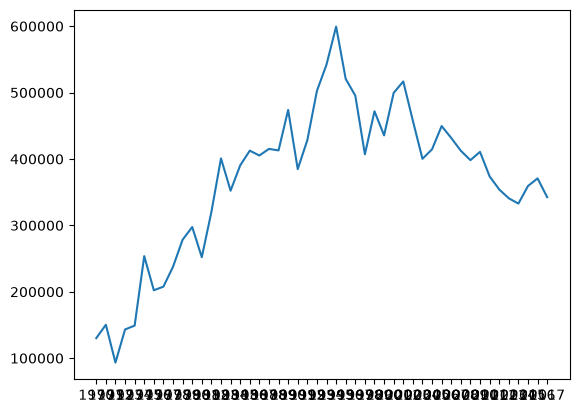

In [13]:
sr_one = df_seoul.loc['경기도']

plt.plot(sr_one.index, sr_one.values)

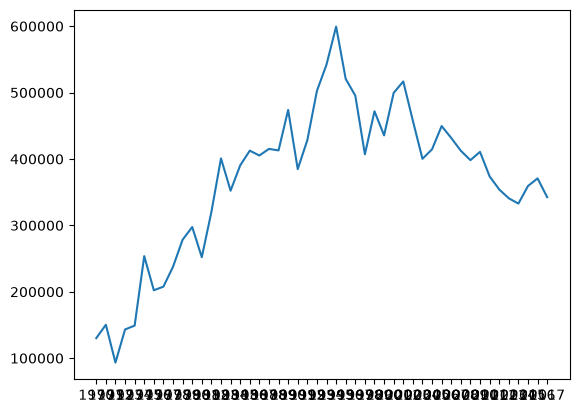

In [14]:
plt.plot(sr_one)
plt.show()

In [17]:
from matplotlib import font_manager, rc
font_path = "./data/malgun.ttf"
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc("font", family=font_name)

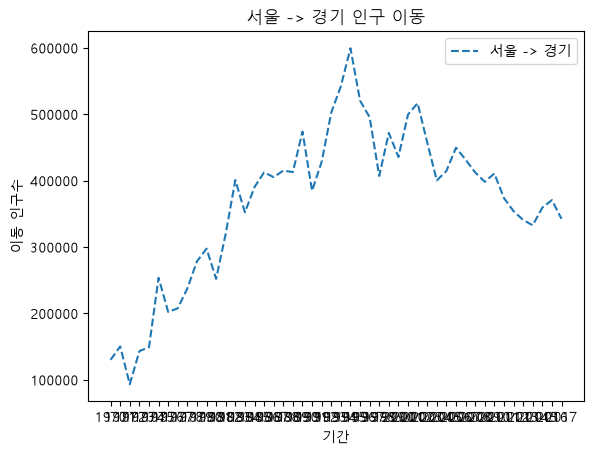

In [18]:
# 차트 제목 / 축 이름 , 선 스타일

plt.plot(sr_one.index, sr_one.values, linestyle="--")

plt.title("서울 -> 경기 인구 이동")
plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.legend(labels=['서울 -> 경기'], loc='best')

plt.show()

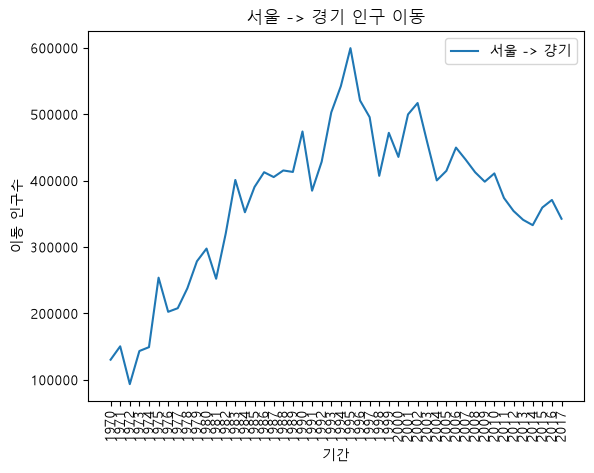

In [26]:
sr_one = df_seoul.loc["경기도"]
plt.Figure(figsize=(14,5))
plt.xticks(rotation='vertical')
plt.plot(sr_one.index, sr_one.values)
plt.title('서울 -> 경기 인구 이동')
plt.xlabel('기간')
plt.ylabel('이동 인구수')
plt.legend(labels = ['서울 -> 걍기'], loc='best' )

plt.show()

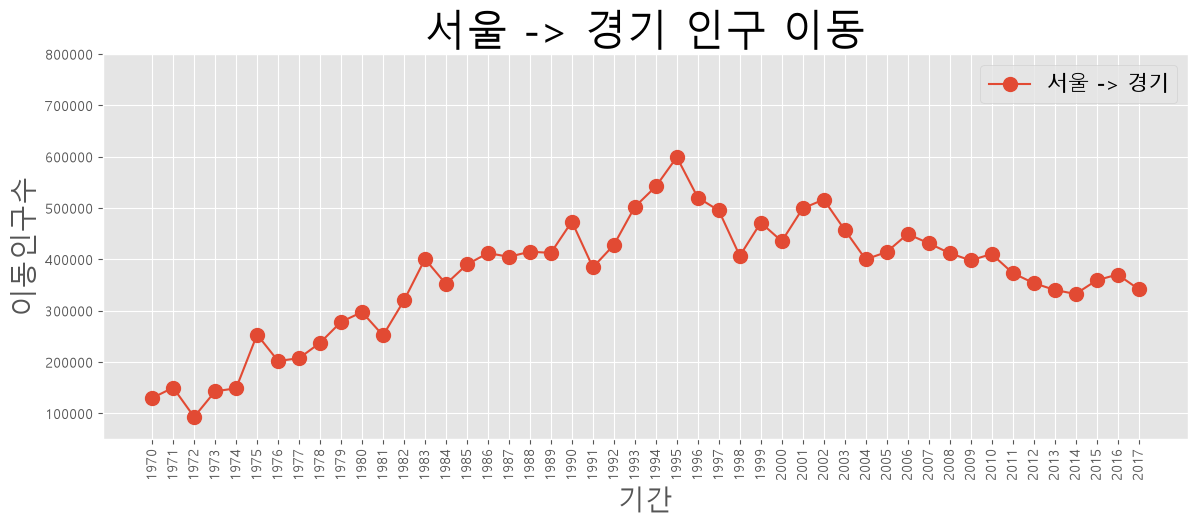

In [33]:
sr_one

plt.style.use("ggplot")

plt.figure(figsize=(14,5))

plt.xticks(size = 10, rotation = 'vertical')

plt.plot(sr_one.index, sr_one.values, marker='o', markersize=10)

plt.title ('서울 -> 경기 인구 이동', size = 30)
plt.xlabel('기간',size = 20)
plt.ylabel('이동인구수',size = 20)

plt.legend(labels=['서울 -> 경기'], loc='best',fontsize=15)

plt.ylim(50000,800000)

plt.annotate('',
             xy=(20, 620000),
             xycoords='data',
             arrowprops=dict(
                 arrowstyle='->',
                 color='skyblue',
                 lw=5
             ))

plt.annotate('',
             xy=(47,450000),
             xycoords='data',
             arrowprops=dict(arrowstyle='->',color='skyblue',lw=5),
             )

plt.show()

In [1]:
# Figure객체, Axes객체
import pandas as pd
import matplotlib.pyplot as plt

samsung_revenue = pd.read_csv("./data/삼성전자_분기별_매출액.csv")
samsung_revenue = samsung_revenue.sort_values('quarter')
samsung_revenue

,value,quarter
5,77203607000000,2022-Q2
4,76781680000000,2022-Q3
3,70464575000000,2022-Q4
2,63745371000000,2023-Q1
1,60005533000000,2023-Q2
0,67404652000000,2023-Q3


In [2]:
fig = plt.figure()
fig

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

(<Figure size 640x480 with 1 Axes>, <Axes: >)

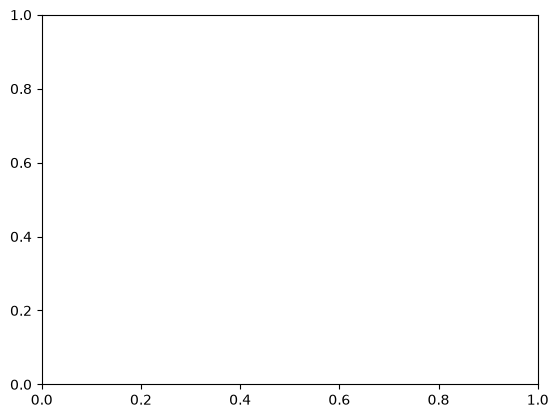

In [5]:
# fig, axe = plt.subplots()

plt.subplots()

In [6]:
print(fig)

Figure(640x480)


In [8]:
print(axe)

Axes(0.125,0.11;0.775x0.77)


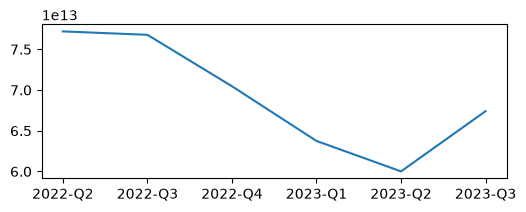

In [9]:
fig, axe = plt.subplots(figsize=(6,2))
axe.plot(samsung_revenue['quarter'],samsung_revenue['value'])
plt.show()

Figure(640x480)
[<Axes: > <Axes: >]


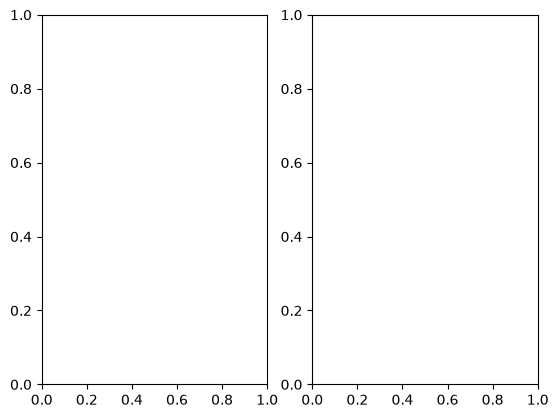

In [10]:
fig, axes = plt.subplots(1,2)
print(fig)
print(axes)

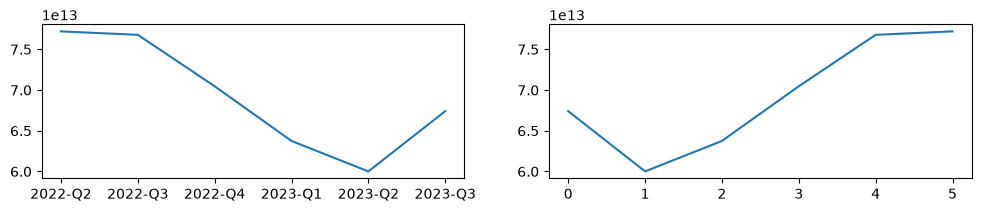

In [11]:
fig, axes = plt.subplots(1,2, figsize =(12,2))
axes[0].plot(samsung_revenue['quarter'], samsung_revenue['value'])
samsung_revenue['value'].plot(ax=axes[1])
plt.show()

Figure(640x480)
[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


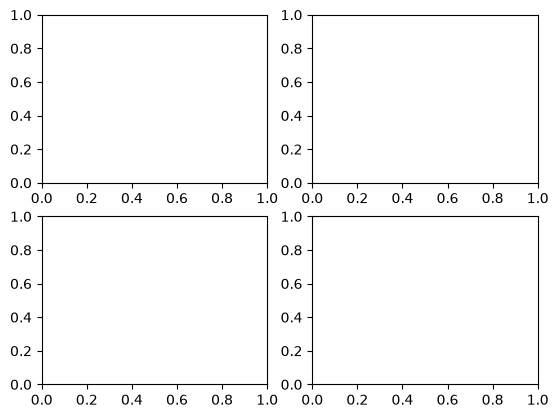

In [15]:
fig,axes = plt.subplots(2,2)
print(fig)
print(axes)

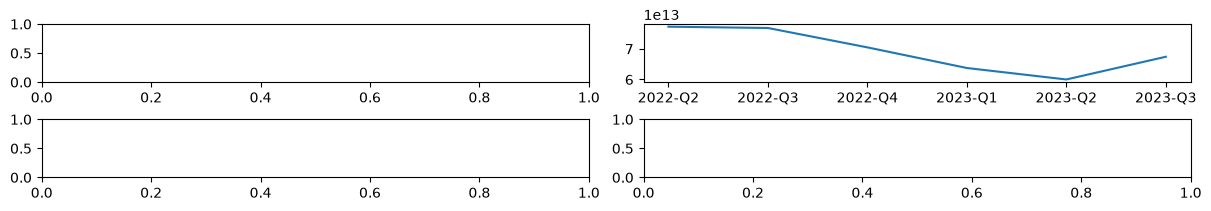

In [13]:
fig, axes = plt.subplots(2,2, figsize =(12,2), constrained_layout = True)
axes[0,1].plot(samsung_revenue['quarter'], samsung_revenue['value'])
plt.show()

Figure(640x480)
{'top_left': <Axes: label='top_left'>, 'right': <Axes: label='right'>, 'bottom_left': <Axes: label='bottom_left'>}


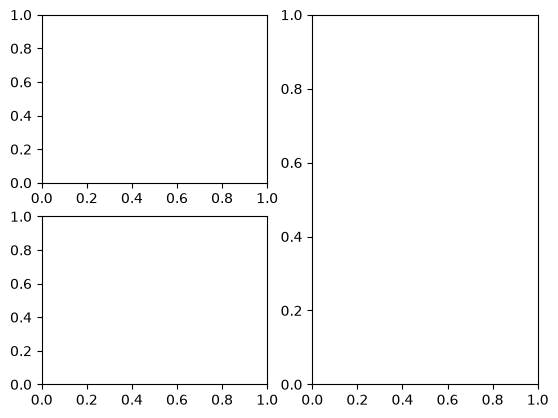

In [16]:
fig,axes = plt.subplot_mosaic([['top_left', 'right'],['bottom_left','right']])

print(fig)
print(axes)

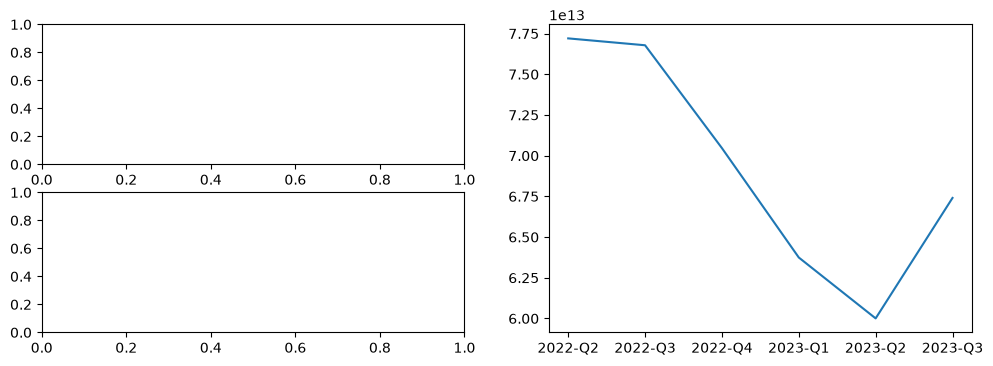

In [17]:
fig,axes = plt.subplot_mosaic([['top_left', 'right'],['bottom_left','right']],figsize =(12,4))

axes['right'].plot(samsung_revenue['quarter'],samsung_revenue['value'])
plt.show()

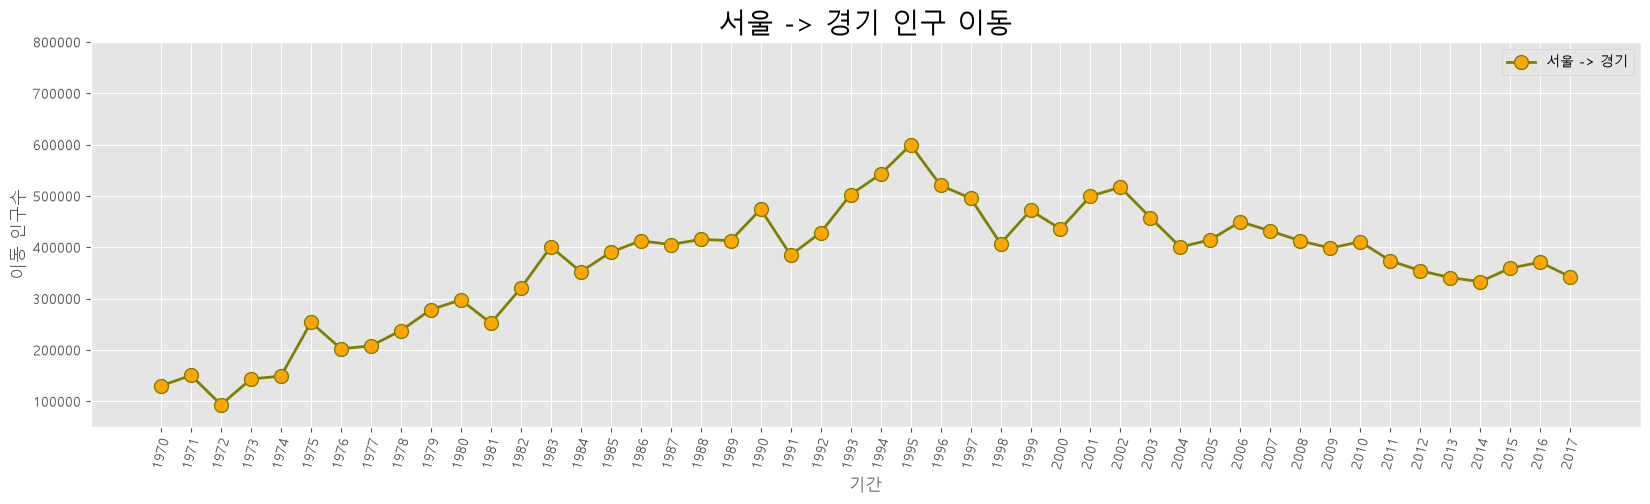

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import font_manager, rc
font_path = "./data/malgun.ttf"   
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

df = pd.read_excel('./data/시도별_전출입_인구수.xlsx')

df = df.ffill()

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시') 
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul = df_seoul.rename({'전입지별':'전입지'}, axis=1)
df_seoul = df_seoul.set_index('전입지')

sr_one = df_seoul.loc['경기도']

plt.style.use('ggplot') 

fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(1,1,1)

ax.plot(sr_one, marker='o', markerfacecolor='orange', markersize=10, 
        color='olive', linewidth=2, label='서울 -> 경기')
ax.legend(loc='best')

ax.set_ylim(50000,800000)

ax.set_title("서울 -> 경기 인구 이동", size = 20)

ax.set_xlabel('기간',size = 12)
ax.set_ylabel('이동 인구수',size = 12)

ax.set_xticks(sr_one.index)
ax.set_xticklabels(sr_one.index, rotation=75)

ax.tick_params(axis="x", labelsize = 10)
ax.tick_params(axis="y", labelsize = 10)

plt.show()

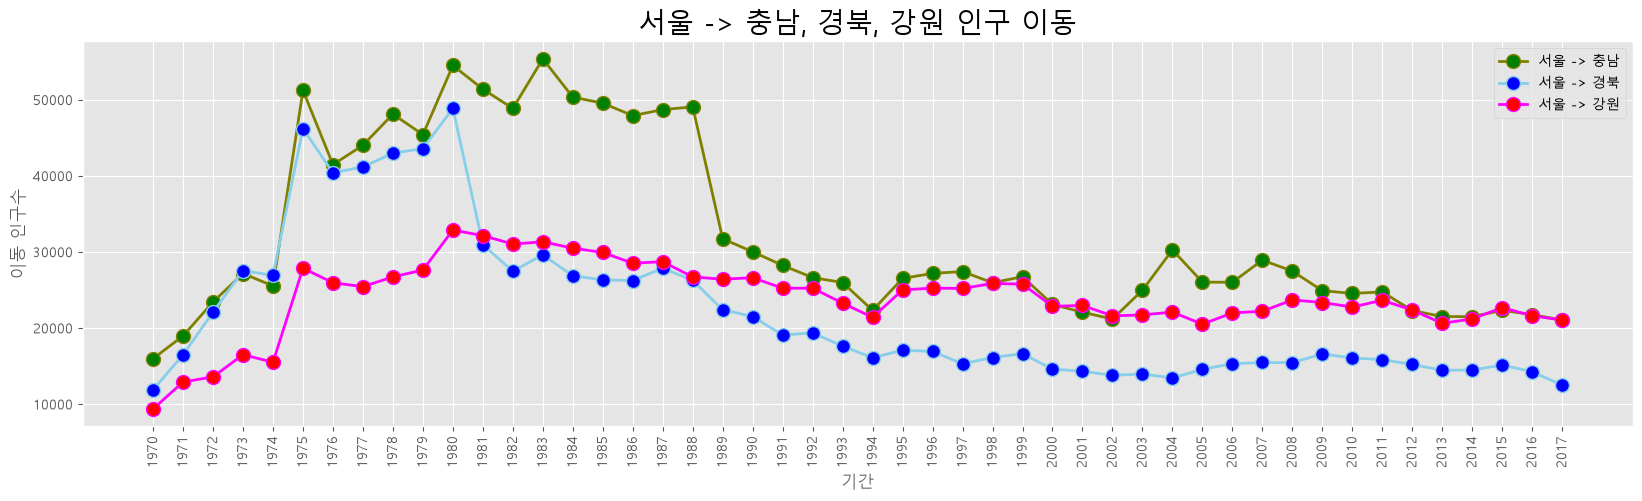

In [26]:
col_years = list(map(str, range(1970,2018)))
df_3 = df_seoul.loc[['충청남도','경상북도','강원도'], col_years]

plt.style.use('ggplot')

fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(1,1,1)

ax.plot(col_years, df_3.loc['충청남도',:], marker='o', markerfacecolor='green', 
        markersize=10, color='olive', linewidth=2, label='서울 -> 충남')
ax.plot(col_years, df_3.loc['경상북도',:], marker='o', markerfacecolor='blue', 
        markersize=10, color='skyblue', linewidth=2, label='서울 -> 경북')
ax.plot(col_years, df_3.loc['강원도',:], marker='o', markerfacecolor='red', 
        markersize=10, color='magenta', linewidth=2, label='서울 -> 강원')

ax.legend(loc='best')

ax.set_title('서울 -> 충남, 경북, 강원 인구 이동', size=20)

ax.set_xlabel('기간', size=12)
ax.set_ylabel('이동 인구수', size = 12)

ax.set_xticks(range(len(col_years)))

ax.set_xticklabels(col_years, rotation=90)

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.show()

[Text(0, 0, '1970'),
 Text(1, 0, '1971'),
 Text(2, 0, '1972'),
 Text(3, 0, '1973'),
 Text(4, 0, '1974'),
 Text(5, 0, '1975'),
 Text(6, 0, '1976'),
 Text(7, 0, '1977'),
 Text(8, 0, '1978'),
 Text(9, 0, '1979'),
 Text(10, 0, '1980'),
 Text(11, 0, '1981'),
 Text(12, 0, '1982'),
 Text(13, 0, '1983'),
 Text(14, 0, '1984'),
 Text(15, 0, '1985'),
 Text(16, 0, '1986'),
 Text(17, 0, '1987'),
 Text(18, 0, '1988'),
 Text(19, 0, '1989'),
 Text(20, 0, '1990'),
 Text(21, 0, '1991'),
 Text(22, 0, '1992'),
 Text(23, 0, '1993'),
 Text(24, 0, '1994'),
 Text(25, 0, '1995'),
 Text(26, 0, '1996'),
 Text(27, 0, '1997'),
 Text(28, 0, '1998'),
 Text(29, 0, '1999'),
 Text(30, 0, '2000'),
 Text(31, 0, '2001'),
 Text(32, 0, '2002'),
 Text(33, 0, '2003'),
 Text(34, 0, '2004'),
 Text(35, 0, '2005'),
 Text(36, 0, '2006'),
 Text(37, 0, '2007'),
 Text(38, 0, '2008'),
 Text(39, 0, '2009'),
 Text(40, 0, '2010'),
 Text(41, 0, '2011'),
 Text(42, 0, '2012'),
 Text(43, 0, '2013'),
 Text(44, 0, '2014'),
 Text(45, 0, '2015')

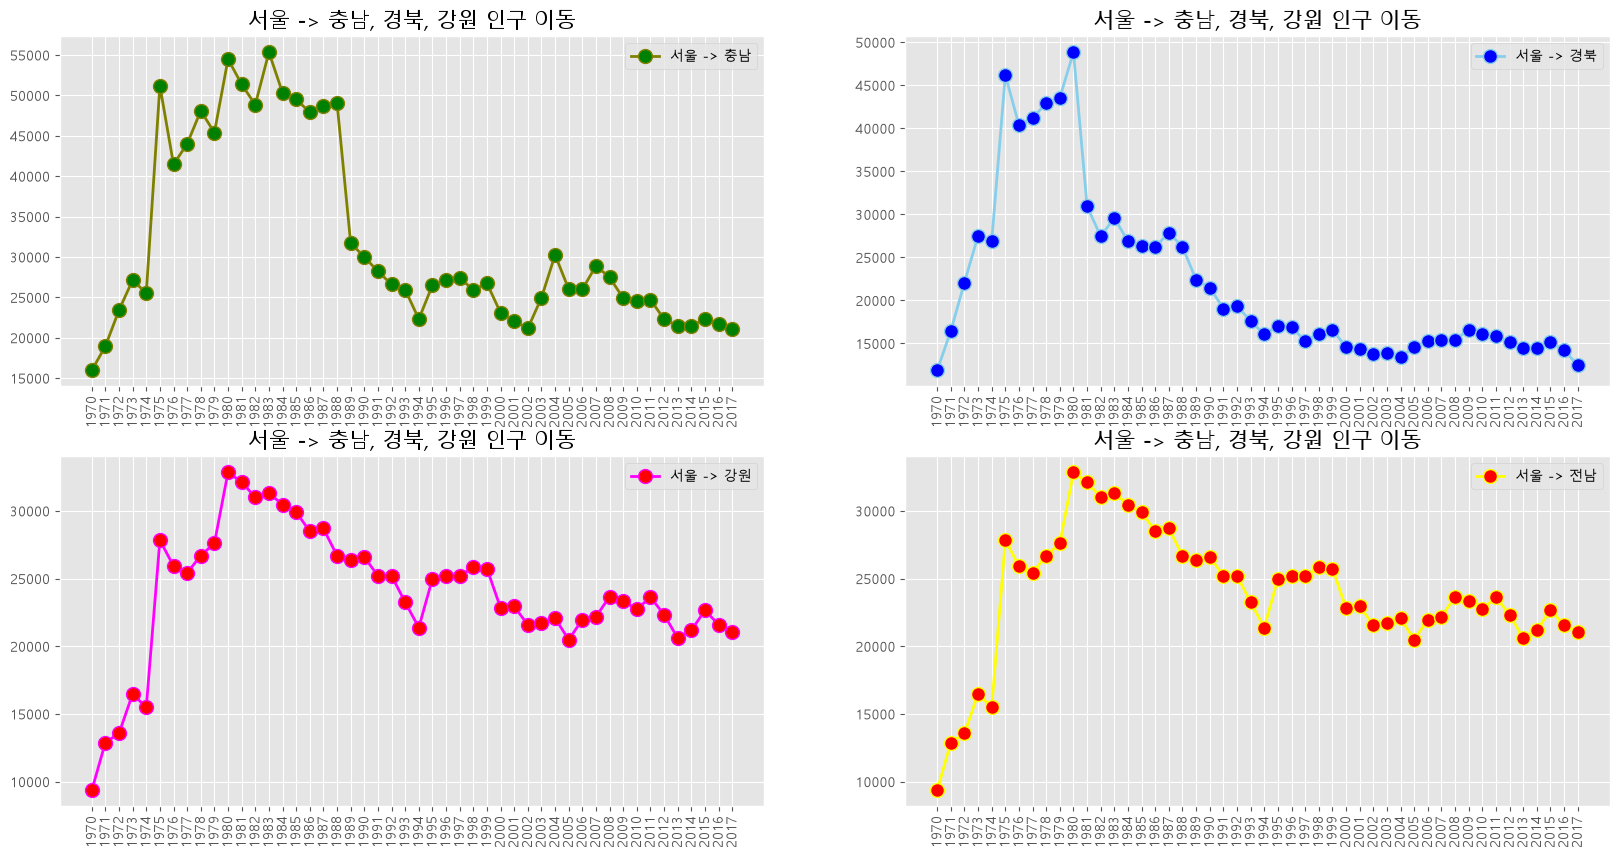

In [27]:
c
plt.style.use('ggplot')

fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

ax1.plot(col_years, df_3.loc['충청남도',:], marker='o', markerfacecolor='green', 
        markersize=10, color='olive', linewidth=2, label='서울 -> 충남')
ax2.plot(col_years, df_3.loc['경상북도',:], marker='o', markerfacecolor='blue', 
        markersize=10, color='skyblue', linewidth=2, label='서울 -> 경북')
ax3.plot(col_years, df_3.loc['강원도',:], marker='o', markerfacecolor='red', 
        markersize=10, color='magenta', linewidth=2, label='서울 -> 강원')
ax4.plot(col_years, df_3.loc['강원도',:], marker='o', markerfacecolor='red', 
        markersize=10, color='yellow', linewidth=2, label='서울 -> 전남')

ax1.legend(loc='best')
ax2.legend(loc='best')
ax3.legend(loc='best')
ax4.legend(loc='best')

ax1.set_title('서울 -> 충남, 경북, 강원 인구 이동', size=15)
ax2.set_title('서울 -> 충남, 경북, 강원 인구 이동', size=15)
ax3.set_title('서울 -> 충남, 경북, 강원 인구 이동', size=15)
ax4.set_title('서울 -> 충남, 경북, 강원 인구 이동', size=15)

ax1.set_xticks(range(len(col_years)))
ax2.set_xticks(range(len(col_years)))
ax3.set_xticks(range(len(col_years)))
ax4.set_xticks(range(len(col_years)))

ax1.set_xticklabels(col_years, rotation=90)
ax2.set_xticklabels(col_years, rotation=90)
ax3.set_xticklabels(col_years, rotation=90)
ax4.set_xticklabels(col_years, rotation=90)

In [31]:
col_years = list(map(str, range(1970,2018)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]
df_4 = df_4.astype(int)
df_4

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
충청남도,15954,18943,23406,27139,25509,51205,41447,43993,48091,45388,...,27458,24889,24522,24723,22269,21486,21473,22299,21741,21020
경상북도,11868,16459,22073,27531,26902,46177,40376,41155,42940,43565,...,15425,16569,16042,15818,15191,14420,14456,15113,14236,12464
강원도,9352,12885,13561,16481,15479,27837,25927,25415,26700,27599,...,23668,23331,22736,23624,22332,20601,21173,22659,21590,21016
전라남도,10513,16755,20157,22160,21314,46610,46251,43430,44624,47934,...,16601,17468,16429,15974,14765,14187,14591,14598,13065,12426


In [35]:
df_4 = df_4.transpose()
df_4.head(7)

전입지,충청남도,경상북도,강원도,전라남도
1970,15954,11868,9352,10513
1971,18943,16459,12885,16755
1972,23406,22073,13561,20157
1973,27139,27531,16481,22160
1974,25509,26902,15479,21314
1975,51205,46177,27837,46610
1976,41447,40376,25927,46251


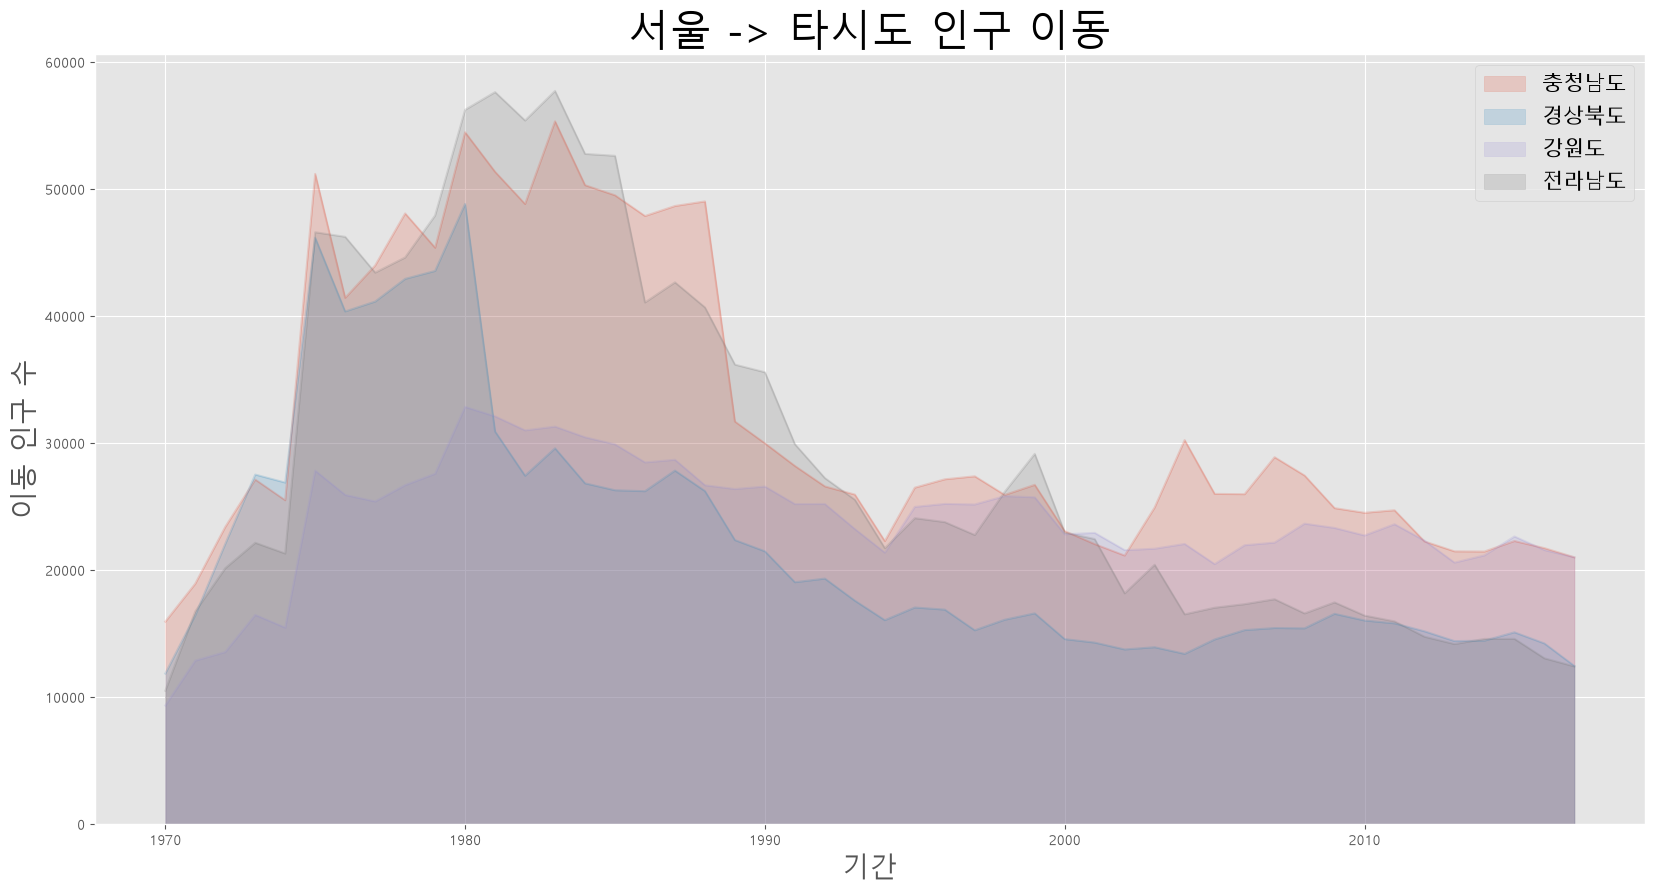

In [36]:
plt.style.use('ggplot')

df_4.plot(kind="area",stacked=False,alpha=0.2,figsize=(20,10))

plt.title('서울 -> 타시도 인구 이동', size = 30)
plt.ylabel('이동 인구 수', size = 20)
plt.xlabel('기간', size = 20)
plt.legend(loc='best', fontsize = 15)
plt.show()

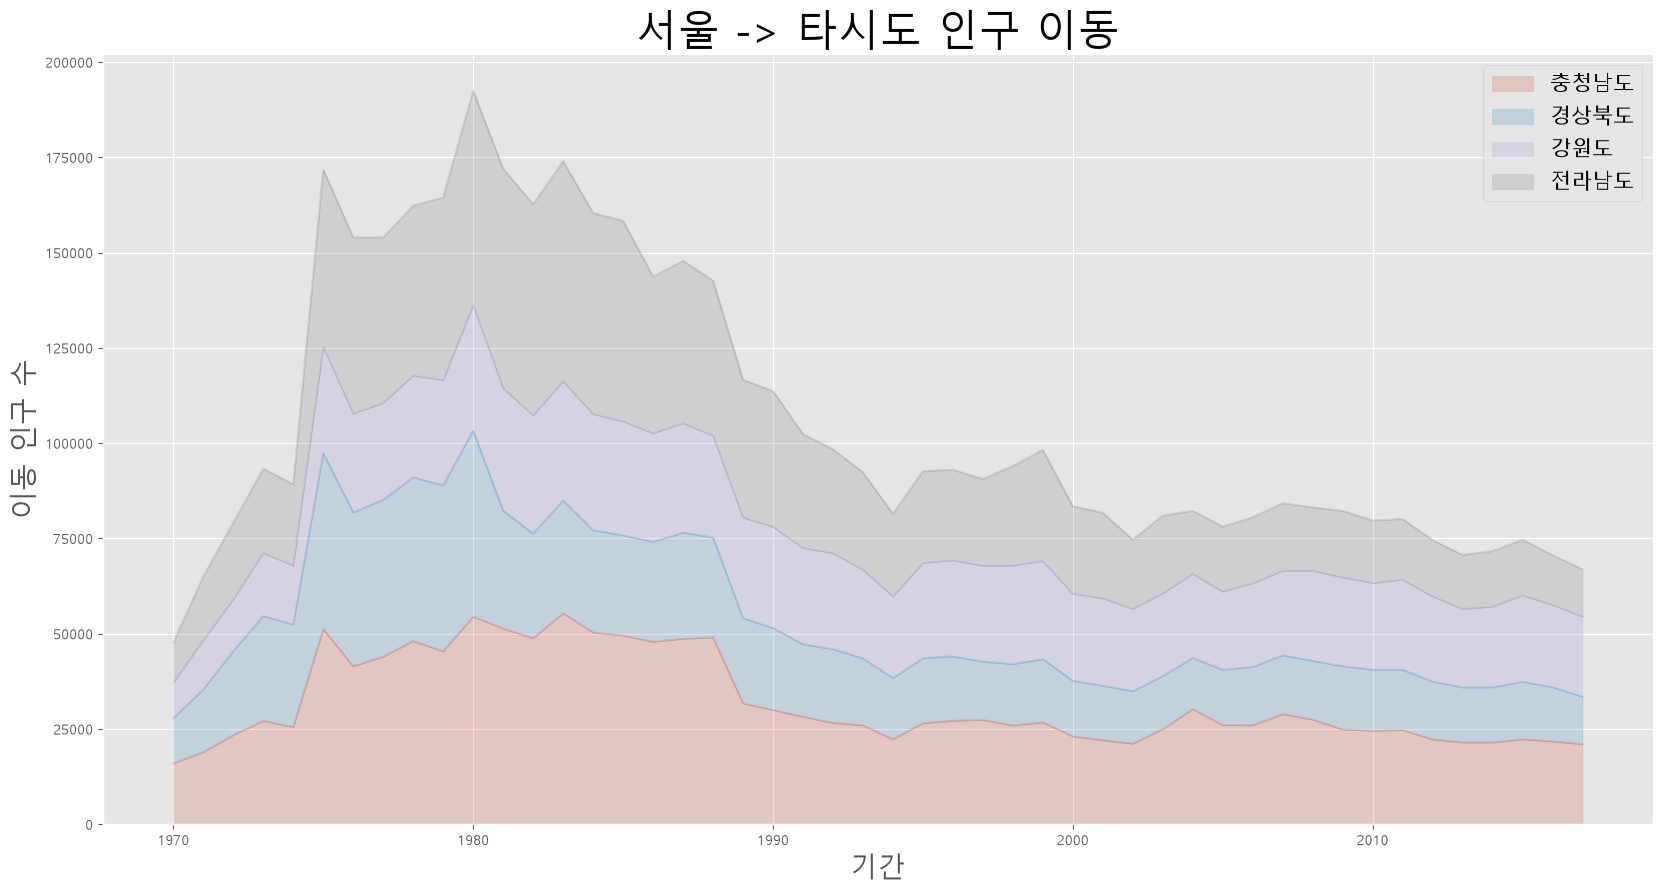

In [37]:
plt.style.use('ggplot')

df_4.plot(kind="area",stacked=True,alpha=0.2,figsize=(20,10))

plt.title('서울 -> 타시도 인구 이동', size = 30)
plt.ylabel('이동 인구 수', size = 20)
plt.xlabel('기간', size = 20)
plt.legend(loc='best', fontsize = 15)
plt.show()

In [42]:
#막대그래프
df_4.head(10)
df_4.index = df_4.index.map(int)
df_4

전입지,충청남도,경상북도,강원도,전라남도
1970,15954,11868,9352,10513
1971,18943,16459,12885,16755
1972,23406,22073,13561,20157
1973,27139,27531,16481,22160
1974,25509,26902,15479,21314
1975,51205,46177,27837,46610
1976,41447,40376,25927,46251
1977,43993,41155,25415,43430
1978,48091,42940,26700,44624
1979,45388,43565,27599,47934


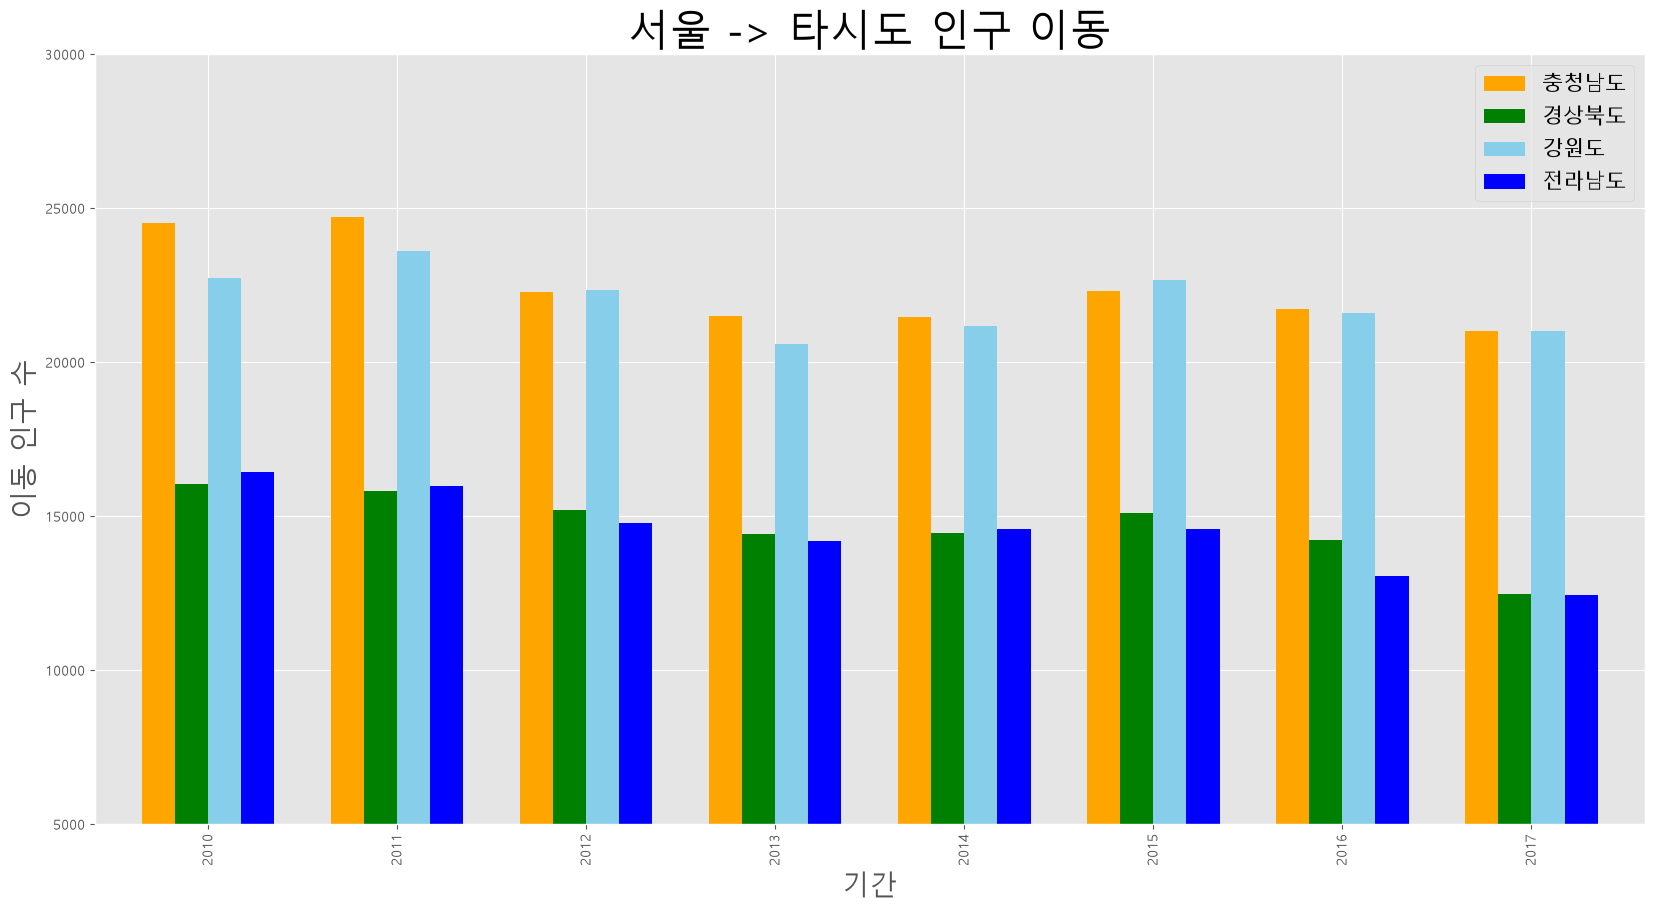

In [47]:
# 막대그래프 그리기
col_years = list(map(str,range(2010,2018)))
col_years = list(map(str, range(2010, 2018)))
df_4 = df_seoul.loc[['충청남도','경상북도', '강원도', '전라남도'], col_years]
df_4 = df_4.transpose()

df_4.plot(
    kind='bar',
    figsize=(20,10),
    width=0.7,
    color=["orange","green","skyblue",'blue']
)

plt.title('서울 -> 타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size=20)
plt.ylim(5000, 30000)
plt.legend(loc='best', fontsize=15)

plt.show()

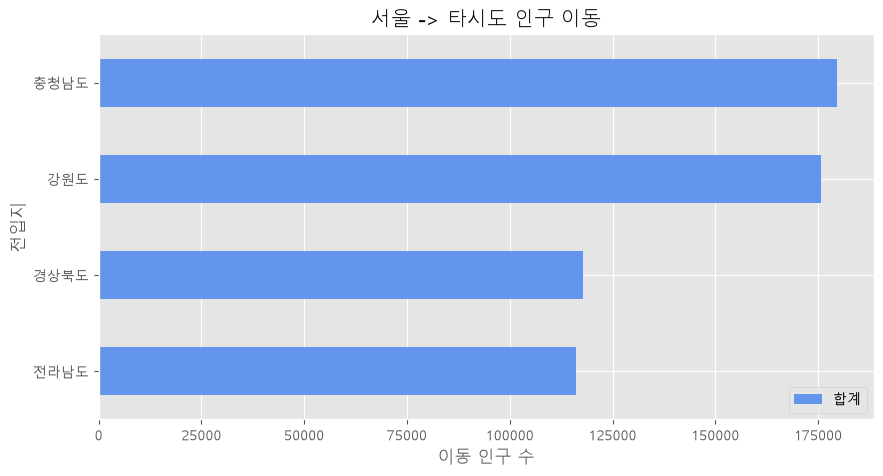

In [50]:
col_years = list(map(str, range(2010, 2018)))
df_4 = df_seoul.loc[['충청남도','경상북도', '강원도', '전라남도'], col_years]

df_4['합계'] = df_4.sum(axis=1)

df_total = df_4[['합계']].sort_values(by='합계', ascending=True)

plt.style.use('ggplot') 

df_total.plot(kind='barh', color='cornflowerblue', width=0.5, figsize=(10, 5))

plt.title('서울 -> 타시도 인구 이동')
plt.ylabel('전입지')
plt.xlabel('이동 인구 수')

plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import font_manager, rc
font_path = "./data/malgun.ttf"
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc("font", family=font_name)

plt.style.use("ggplot")
plt.rcParams["axes.unicode_minus"]=False

In [7]:
df = pd.read_excel('./data/남북한발전전력량.xlsx')
df = df.loc[5:9]
df

,전력량 (억㎾h),발전 전력별,1990,1991,1992,1993,1994,1995,1996,1997,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
5,북한,합계,277,263,247,221,231,230,213,193,...,236,255,235,237,211,215,221,216,190,239
6,NaN,수력,156,150,142,133,138,142,125,107,...,133,141,125,134,132,135,139,130,100,128
7,NaN,화력,121,113,105,88,93,88,88,86,...,103,114,110,103,79,80,82,86,90,111
8,NaN,원자력,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-


In [8]:
df.drop("전력량 (억㎾h)", axis="columns", inplace=True)
df.set_index('발전 전력별', inplace=True)
df = df.T
df.head()

발전 전력별,합계,수력,화력,원자력
1990,277,156,121,-
1991,263,150,113,-
1992,247,142,105,-
1993,221,133,88,-
1994,231,138,93,-


In [13]:
for col in df.columns:
    df[col] = df[col].replace("-","0")


In [15]:
df = df.astype(float)
df.info()

<class 'pandas.DataFrame'>
Index: 27 entries, 1990 to 2016
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   합계      27 non-null     float64
 1   수력      27 non-null     float64
 2   화력      27 non-null     float64
 3   원자력     27 non-null     float64
dtypes: float64(4)
memory usage: 1.1+ KB


In [18]:
df.head()

발전 전력별,합계,수력,화력,원자력
1990,277.0,156.0,121.0,0.0
1991,263.0,150.0,113.0,0.0
1992,247.0,142.0,105.0,0.0
1993,221.0,133.0,88.0,0.0
1994,231.0,138.0,93.0,0.0


In [19]:
df = df.rename(columns={"합계":"총발전량"})
df.head()

발전 전력별,총발전량,수력,화력,원자력
1990,277.0,156.0,121.0,0.0
1991,263.0,150.0,113.0,0.0
1992,247.0,142.0,105.0,0.0
1993,221.0,133.0,88.0,0.0
1994,231.0,138.0,93.0,0.0


In [22]:
df["총발전량 - 1년"] = df["총발전량"].shift(1)
df.head()

발전 전력별,총발전량,수력,화력,원자력,총발전량 - 1년
1990,277.0,156.0,121.0,0.0,NaN
1991,263.0,150.0,113.0,0.0,277.0
1992,247.0,142.0,105.0,0.0,263.0
1993,221.0,133.0,88.0,0.0,247.0
1994,231.0,138.0,93.0,0.0,221.0


In [24]:
df['증감율'] = ((df['총발전량'] / df['총발전량 - 1년']) - 1 ) * 100
df.head()

발전 전력별,총발전량,수력,화력,원자력,총발전량 - 1년,증감율
1990,277.0,156.0,121.0,0.0,NaN,NaN
1991,263.0,150.0,113.0,0.0,277.0,-5.054152
1992,247.0,142.0,105.0,0.0,263.0,-6.083650
1993,221.0,133.0,88.0,0.0,247.0,-10.526316
1994,231.0,138.0,93.0,0.0,221.0,4.524887


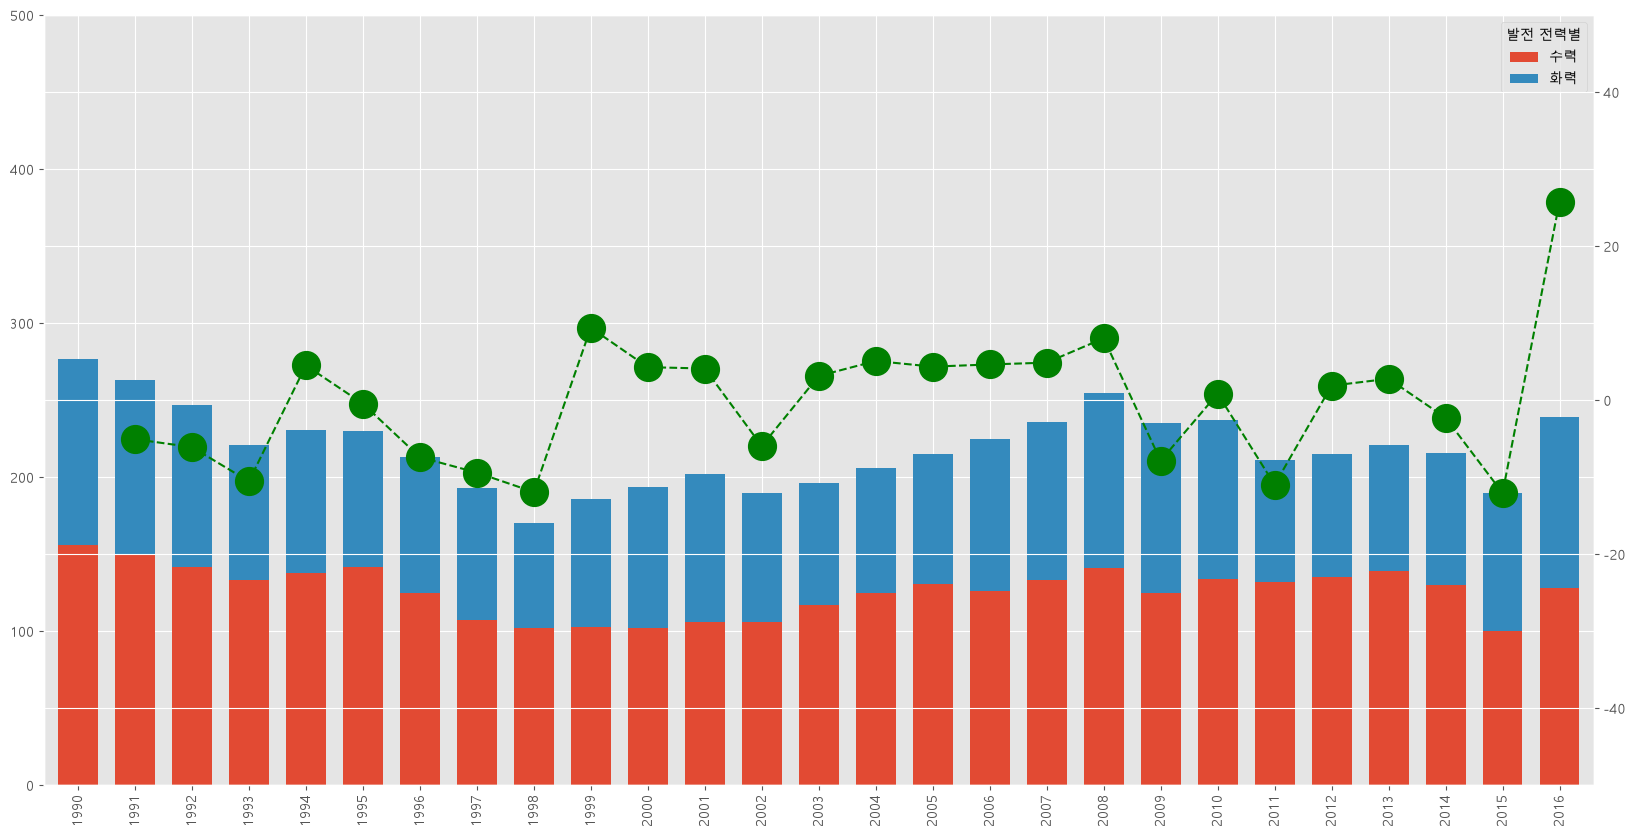

In [34]:
ax1 = df[["수력","화력"]].plot(
    kind="bar",
    figsize=(20,10),
    width=0.7,
    stacked=True
)

ax2 = ax1.twinx()
ax2.plot(df.index, df.증감율, ls='--', marker='o', markersize=20, 
         color='green', label='전년대비 증감율(%)')  

ax1.set_ylim(0,500)
ax2.set_ylim(-50,50)

plt.show()


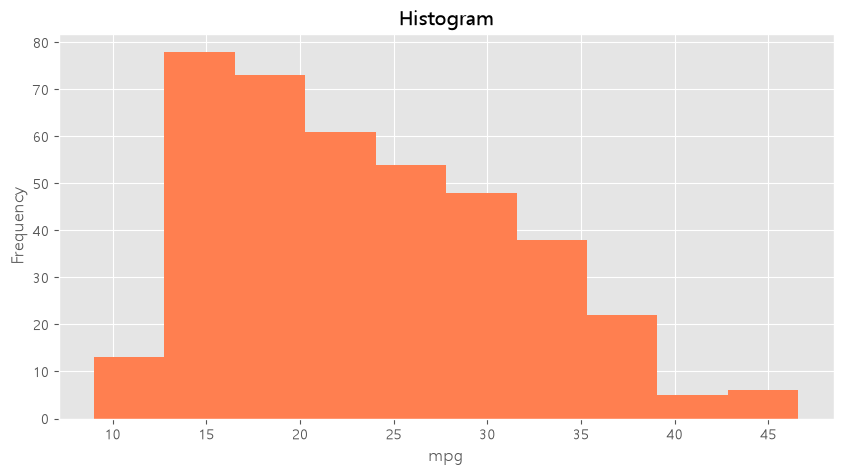

In [39]:
#히스토그램
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

df = pd.read_csv('./data/auto-mpg.csv',header=None)
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

df["mpg"].plot(
    kind='hist',
    bins=10,
    color="coral",
    figsize=(10,5)
)

plt.title('Histogram')
plt.xlabel('mpg')
plt.show()

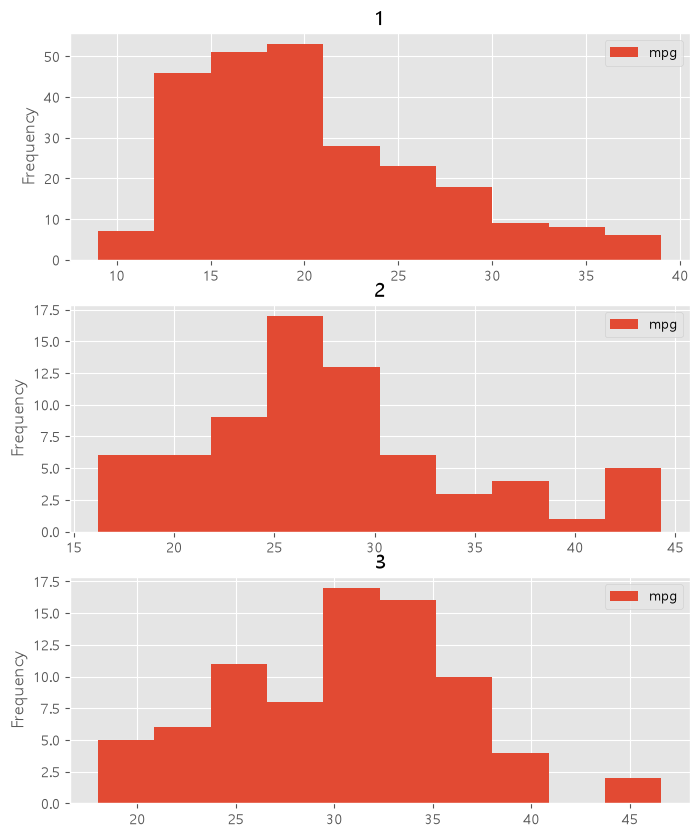

In [40]:
df[['mpg','origin']].plot(by=['origin'],kind='hist',figsize=(8,10));

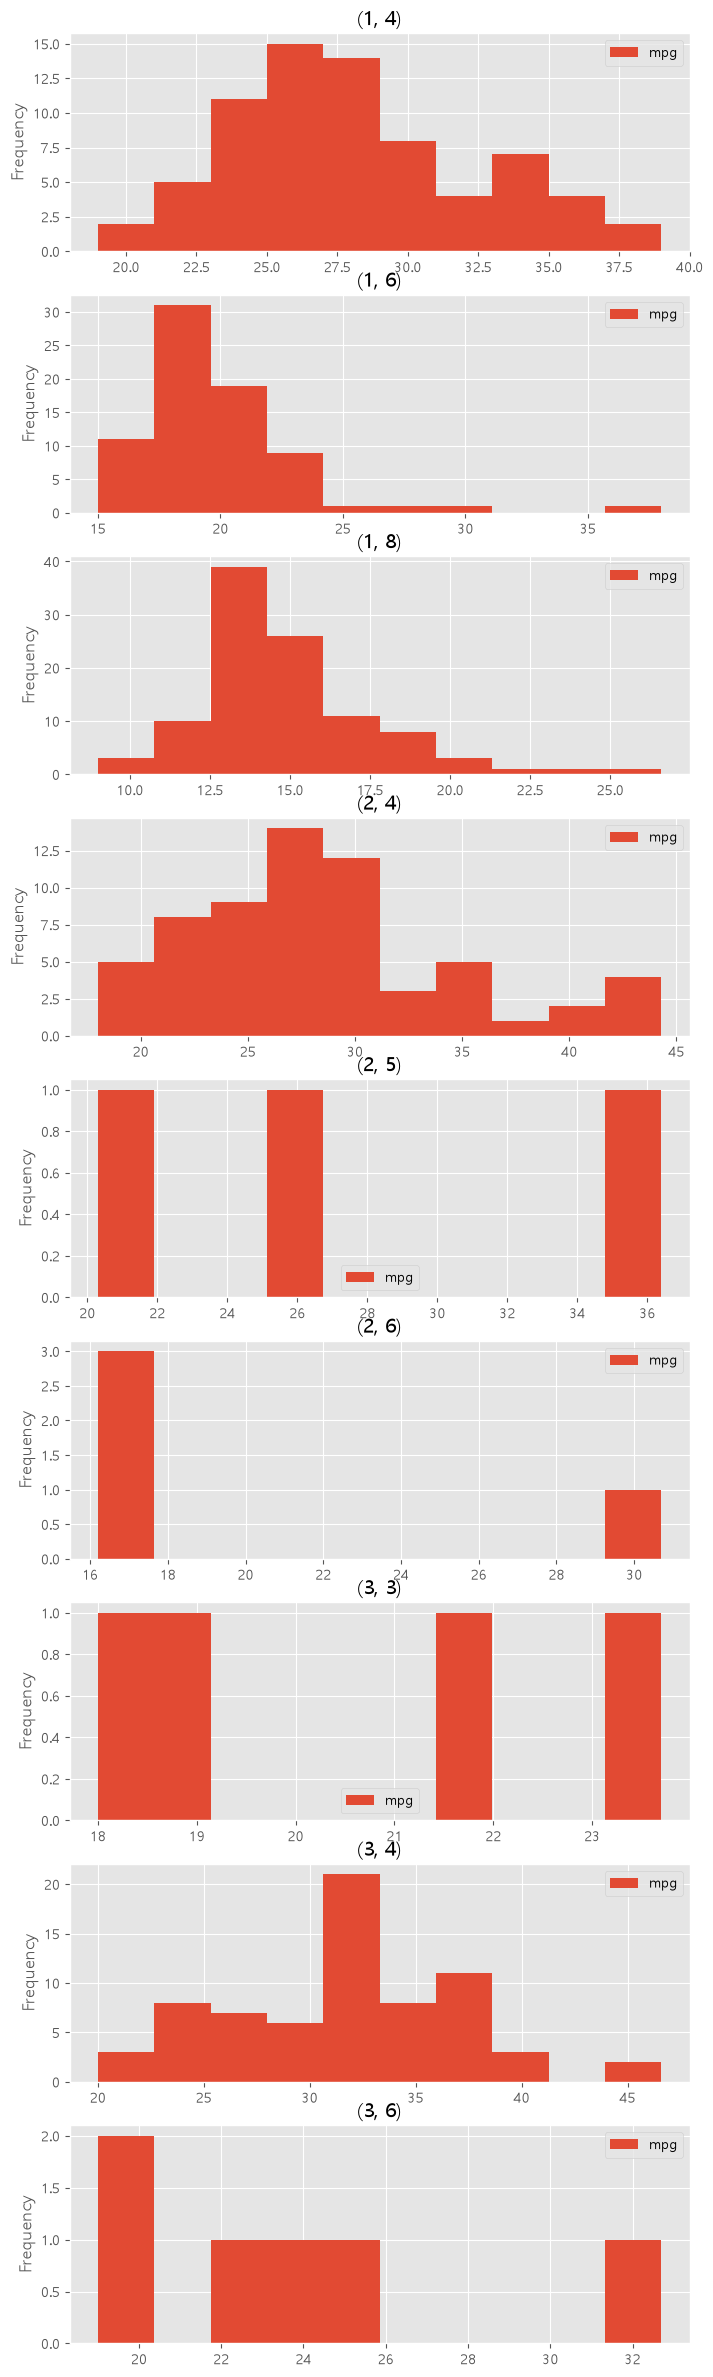

In [41]:
df[['mpg','origin','cylinders']].plot(by=['origin','cylinders'],kind='hist',figsize=(8,30));

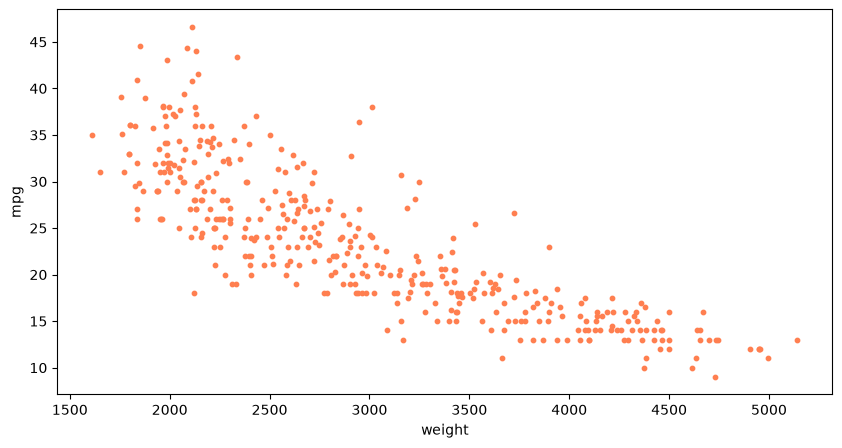

In [42]:
#산점도

plt.style.use("default")

df.plot(
    kind="scatter",
    x="weight",
    y="mpg",
    c="coral",
    s=10,
    figsize=(10,5)
)

plt.show()

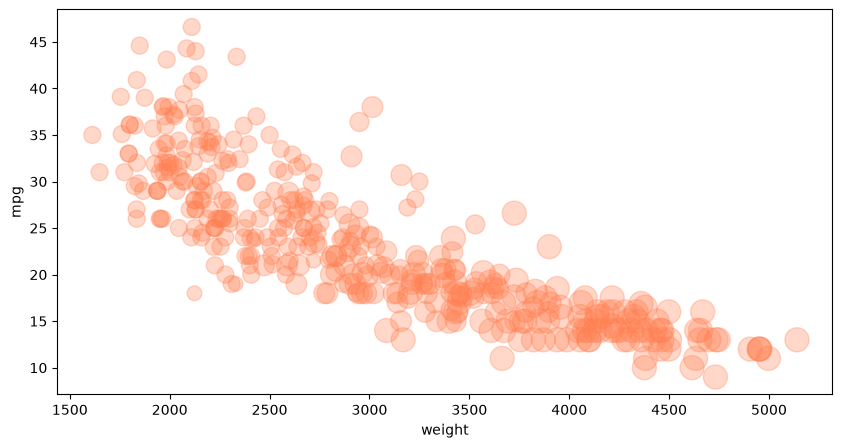

In [43]:
plt.style.use("default")

cylinders_size = (df.cylinders / df.cylinders.max()) * 300


df.plot(
    kind="scatter",
    x="weight",
    y="mpg",
    c="coral",
    s=cylinders_size,
    figsize=(10,5),
    alpha = 0.3
)

plt.show()

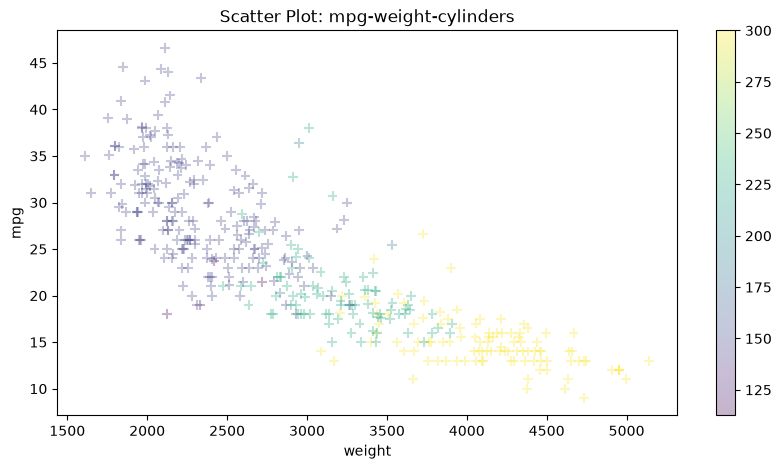

In [44]:
cylinders_size = (df['cylinders'] / df['cylinders'].max()) * 300

df.plot(kind='scatter', x='weight', y='mpg', marker='+', figsize=(10, 5),
        cmap='viridis', c=cylinders_size, s=50, alpha=0.3)
plt.title('Scatter Plot: mpg-weight-cylinders')

plt.savefig("./data/scatter.png")   
plt.savefig("./data/scatter_transparent.png", transparent=True)   

plt.show()

In [45]:
#파이 차트

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [48]:
df['count'] = 1
df_origin = df.groupby("origin").sum(numeric_only=True)
df_origin.head()

,mpg,cylinders,displacement,weight,acceleration,model year,coint,count
origin,,,,,,,,
1,5000.8,1556,61229.5,837121.0,3743.4,18827,249,249
2,1952.4,291,7640.0,169631.0,1175.1,5307,70,70
3,2405.6,324,8114.0,175477.0,1277.6,6118,79,79


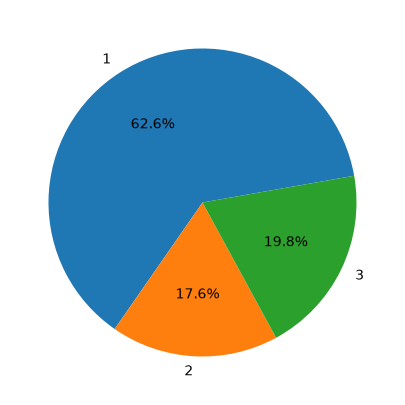

In [50]:
df_origin["count"].plot(
    kind="pie",
    figsize=(7,5),
    autopct="%1.1f%%",
    startangle=10,
    color=["chocolate","bisque","cadetblue"]
)

plt.show()

In [52]:
#박스플롯

plt.style.use("grayscale")
plt.rcParams['axes.unicode_minus'] = False

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name,coint,count
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,1,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,1,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,1,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,1,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino,1,1


C:\Users\kdt66\AppData\Local\Temp\ipykernel_4228\1516284541.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax2.boxplot(


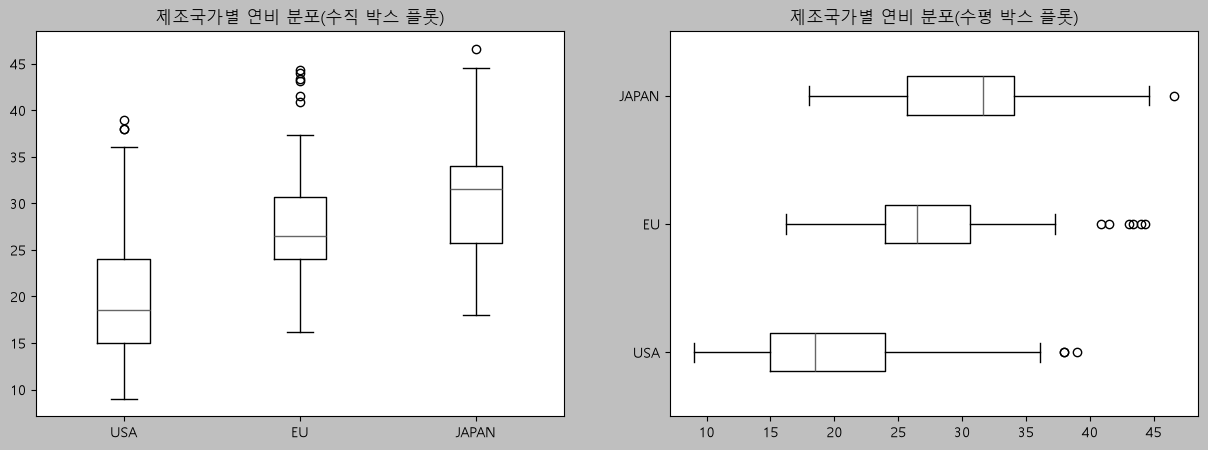

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import font_manager, rc
font_path = "./data/malgun.ttf"   
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

plt.style.use('grayscale')          
plt.rcParams['axes.unicode_minus']=False   

df = pd.read_csv('./data/auto-mpg.csv', header=None)

df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']


fig, (ax1,ax2) = plt.subplots(1,2, figsize=(15,5))

ax1.boxplot(
    x=[
        df[df['origin'] == 1]['mpg'],
        df[df['origin'] == 2]['mpg'],
        df[df['origin'] == 3]['mpg']
    ],
    tick_labels=['USA', 'EU', 'JAPAN']
)

ax2.boxplot(
    x=[
        df[df['origin'] == 1]['mpg'],
        df[df['origin'] == 2]['mpg'],
        df[df['origin'] == 3]['mpg']
    ],
    tick_labels=['USA', 'EU', 'JAPAN'],
    vert=False
)

ax1.set_title('제조국가별 연비 분포(수직 박스 플롯)')
ax2.set_title('제조국가별 연비 분포(수평 박스 플롯)')

plt.show()